# Three-Input Ablation — ROI Effect Isolated (Original Recipe)
### DenseNet121 vs EfficientNet-B2 vs ResNet-50 vs VGG-16

**Why this notebook exists:** `three_input_coach_comparison.ipynb` (ROI input + partial-unfreeze +
label smoothing + extra augmentation, all changed at once relative to the two-input baseline)
regressed accuracy on every architecture tested so far (DenseNet121 -7.9pp, ResNet-50 -1.1pp,
EfficientNet-B2 -1.8pp vs `architecture_comparison_test_metrics.csv`). That result is confounded —
four things changed simultaneously, so it can't tell us whether the ROI mask itself hurts, or
whether the overfitting-fix bundle (particularly partial-unfreeze restricting how much the new,
very-unlike-ImageNet ROI branch can adapt, or label-smoothing interacting badly with the
val_loss-based checkpoint/early-stopping selection) is the actual cause.

**This notebook changes exactly one thing** versus `architecture_comparison.ipynb`: it adds the ROI
mask as a third input branch. Everything else — full backbone unfreeze in Phase 2, plain
`nn.CrossEntropyLoss()` (no label smoothing), and the original augmentation only (no `RandomAffine`,
no `RandomErasing`) — is identical to the proven two-input recipe. If this run's accuracy is
comparable to or better than the two-input baseline, the ROI mask has real value and the overfitting
fixes need separate tuning. If it's still worse, the ROI mask itself is the problem (likely because
the crop image already captures most of the localization signal, and the mask mostly adds noise from
a modality very unlike anything backbones pretrained on ImageNet have seen).


In [1]:
# --- Install / import dependencies ---
import os, time, json, random, warnings, gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
print("PyTorch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


PyTorch: 2.11.0+cu128 | CUDA available: True


In [2]:
# --- Load dataframes produced by ../roi_caching.ipynb ---
train_df = pd.read_csv("../../dataframes/train_df_with_roi.csv")
val_df   = pd.read_csv("../../dataframes/val_df_with_roi.csv")
test_df  = pd.read_csv("../../dataframes/test_df_with_roi.csv")

print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))
print("(rows without a resolvable ROI mask were already dropped during caching)")


train: 2513 val: 317 test: 320
(rows without a resolvable ROI mask were already dropped during caching)


In [3]:
# --- Global configuration -- identical to architecture_comparison.ipynb, no overfitting-fix params ---
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
NUM_WORKERS = 4 if os.name != "nt" else 0

HEAD_WARMUP_EPOCHS = 5      # Phase 1: all three backbones frozen, heads-only
MAX_EPOCHS = 40             # capped per-experiment budget (Phase 1 + Phase 2)
EARLY_STOPPING_PATIENCE = 8

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

FULL_PATH_COL = "full image cached path"
CROP_PATH_COL = "cropped image cached path"
ROI_PATH_COL  = "roi mask cached path"
LABEL_COL = "pathology"
CLASS_NAMES = ["Benign", "Malignant"]

# Exactly the Stage 0 baseline hyperparameters from architecture_comparison.ipynb. No label
# smoothing, no partial-unfreeze fraction, no extra augmentation -- the only variable under test
# is the added ROI branch.
BASELINE = dict(
    head_lr=1e-4,
    backbone_lr=1e-5,
    weight_decay=1e-4,
    scheduler="plateau",   # "plateau" | "cosine" | "onecycle"
)

ARCHITECTURES = ["densenet121", "resnet50", "efficientnet_b2", "vgg16"]
ARCH_DISPLAY_NAMES = {
    "densenet121": "DenseNet121",
    "resnet50": "ResNet-50",
    "efficientnet_b2": "EfficientNet-B2",
    "vgg16": "VGG-16",
}

RESULTS_DIR = "results"
CKPT_DIR = "checkpoints"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## Dataset and transforms -- unchanged from `architecture_comparison.ipynb` (no RandomAffine, no RandomErasing)

In [4]:
def encode_label(raw_label):
    try:
        return int(raw_label)
    except (ValueError, TypeError):
        pass
    text = str(raw_label).strip().upper()
    return 1 if "MALIGNANT" in text else 0


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class TripleImageDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_image = Image.open(row[FULL_PATH_COL]).convert("RGB")
        cropped_image = Image.open(row[CROP_PATH_COL]).convert("RGB")
        roi_image = Image.open(row[ROI_PATH_COL]).convert("RGB")
        full_image = self.transform(full_image)
        cropped_image = self.transform(cropped_image)
        roi_image = self.transform(roi_image)
        label = torch.tensor(encode_label(row[LABEL_COL]), dtype=torch.long)
        return full_image, cropped_image, roi_image, label


def make_loaders(batch_size=BATCH_SIZE):
    train_loader = DataLoader(
        TripleImageDataset(train_df, train_transform), batch_size=batch_size,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    )
    val_loader = DataLoader(
        TripleImageDataset(val_df, eval_transform), batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )
    test_loader = DataLoader(
        TripleImageDataset(test_df, eval_transform), batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )
    return train_loader, val_loader, test_loader


## Three-input model -- full backbone unfreeze in Phase 2 (matches `architecture_comparison.ipynb`'s
`set_backbones_trainable(True/False)` pattern exactly, just extended to three branches instead of two)

In [5]:
def build_backbone(arch):
    if arch == "densenet121":
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        base = models.densenet121(weights=weights)
        extractor = nn.Sequential(base.features, nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d((1, 1)))
        dim = 1024
    elif arch == "resnet50":
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        base = models.resnet50(weights=weights)
        extractor = nn.Sequential(*list(base.children())[:-1])
        dim = 2048
    elif arch == "efficientnet_b2":
        weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1
        base = models.efficientnet_b2(weights=weights)
        extractor = nn.Sequential(base.features, nn.AdaptiveAvgPool2d((1, 1)))
        dim = 1408
    elif arch == "vgg16":
        weights = models.VGG16_Weights.IMAGENET1K_V1
        base = models.vgg16(weights=weights)
        extractor = nn.Sequential(base.features, nn.AdaptiveAvgPool2d((1, 1)))
        dim = 512
    else:
        raise ValueError(f"Unknown architecture: {arch}")
    return extractor, dim


class TripleInputModel(nn.Module):
    """Full mammogram + cropped lesion + ROI mask, each through its own backbone
    instance, concatenated into a shared classifier."""

    def __init__(self, arch, num_classes=2, dropout=0.5):
        super().__init__()
        self.arch = arch
        self.full_extractor, feat_dim = build_backbone(arch)
        self.crop_extractor, _ = build_backbone(arch)
        self.roi_extractor, _ = build_backbone(arch)
        combined_dim = feat_dim * 3
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 512), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, full_image, cropped_image, roi_image):
        full_feat = torch.flatten(self.full_extractor(full_image), 1)
        crop_feat = torch.flatten(self.crop_extractor(cropped_image), 1)
        roi_feat = torch.flatten(self.roi_extractor(roi_image), 1)
        combined = torch.cat([full_feat, crop_feat, roi_feat], dim=1)
        return self.classifier(combined)

    def set_backbones_trainable(self, trainable: bool):
        for extractor in (self.full_extractor, self.crop_extractor, self.roi_extractor):
            for p in extractor.parameters():
                p.requires_grad = trainable
            extractor.train(trainable)


## Metrics, epoch runner, scheduler (identical to `architecture_comparison.ipynb`, extended to 3 inputs)

In [6]:
def compute_metrics(labels, preds, probs):
    acc = accuracy_score(labels, preds)
    sensitivity = recall_score(labels, preds, pos_label=1, zero_division=0)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    f1 = f1_score(labels, preds, zero_division=0)
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float("nan")
    return {
        "accuracy": acc, "sensitivity": sensitivity, "specificity": specificity,
        "f1": f1, "roc_auc": auc,
    }


def run_epoch(model, loader, device, criterion, optimizer=None, scaler=None, use_amp=False, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    grad_context = torch.enable_grad() if is_train else torch.no_grad()
    with grad_context:
        for full_imgs, crop_imgs, roi_imgs, labels in tqdm(loader, desc=desc, leave=False):
            full_imgs = full_imgs.to(device, non_blocking=True)
            crop_imgs = crop_imgs.to(device, non_blocking=True)
            roi_imgs = roi_imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(full_imgs, crop_imgs, roi_imgs)
                loss = criterion(outputs, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return avg_loss, metrics


def build_scheduler(name, optimizer, steps_per_epoch=None, total_epochs=None):
    if name == "plateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=5), "epoch"
    if name == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(total_epochs, 1)), "epoch"
    if name == "onecycle":
        max_lrs = [g["lr"] for g in optimizer.param_groups]
        sched = optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=max_lrs, steps_per_epoch=steps_per_epoch, epochs=total_epochs,
        )
        return sched, "batch"
    raise ValueError(f"Unknown scheduler: {name}")


## Training loop -- two-phase, full unfreeze in Phase 2, plain CrossEntropyLoss (no label smoothing)

In [7]:
def train_experiment(exp_name, arch, head_lr, backbone_lr, weight_decay, scheduler_name,
                      train_loader, val_loader, max_epochs=MAX_EPOCHS):
    set_seed(SEED)
    print(f"\n{'=' * 80}\nExperiment: {exp_name}  (arch={arch})\n"
          f"head_lr={head_lr} backbone_lr={backbone_lr} weight_decay={weight_decay} "
          f"scheduler={scheduler_name} | full unfreeze, no label smoothing\n{'=' * 80}")

    model = TripleInputModel(arch).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    ckpt_path = os.path.join(CKPT_DIR, f"{exp_name}.pth")

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_loss, best_val_acc, global_epoch = float("inf"), 0.0, 0
    start_time = time.time()

    # ---- Phase 1: head warmup, all backbones frozen ----
    model.set_backbones_trainable(False)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=head_lr, weight_decay=weight_decay,
    )
    for _ in range(min(HEAD_WARMUP_EPOCHS, max_epochs)):
        global_epoch += 1
        tr_loss, tr_m = run_epoch(model, train_loader, DEVICE, criterion, optimizer, scaler, use_amp,
                                   desc=f"{exp_name} e{global_epoch} [warmup-train]")
        va_loss, va_m = run_epoch(model, val_loader, DEVICE, criterion,
                                   desc=f"{exp_name} e{global_epoch} [warmup-val]")
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
        history["lr"].append(optimizer.param_groups[0]["lr"])
        print(f"  [warmup] epoch {global_epoch:2d} | train_loss {tr_loss:.4f} acc {tr_m['accuracy']:.4f} "
              f"| val_loss {va_loss:.4f} acc {va_m['accuracy']:.4f}")
        if va_loss < best_val_loss:
            best_val_loss, best_val_acc = va_loss, va_m["accuracy"]
            torch.save({"epoch": global_epoch - 1, "model_state_dict": model.state_dict(),
                        "val_accuracy": va_m["accuracy"], "val_loss": va_loss}, ckpt_path)

    # ---- Phase 2: unfreeze all three backbones, discriminative LR ----
    model.set_backbones_trainable(True)
    optimizer = optim.AdamW([
        {"params": model.full_extractor.parameters(), "lr": backbone_lr},
        {"params": model.crop_extractor.parameters(), "lr": backbone_lr},
        {"params": model.roi_extractor.parameters(), "lr": backbone_lr},
        {"params": model.classifier.parameters(), "lr": head_lr},
    ], weight_decay=weight_decay)

    remaining_epochs = max(max_epochs - HEAD_WARMUP_EPOCHS, 0)
    scheduler, step_mode = build_scheduler(scheduler_name, optimizer,
                                            steps_per_epoch=len(train_loader), total_epochs=max(remaining_epochs, 1))
    epochs_no_improve = 0

    for _ in range(remaining_epochs):
        global_epoch += 1
        tr_loss, tr_m = run_epoch(model, train_loader, DEVICE, criterion, optimizer, scaler, use_amp,
                                   desc=f"{exp_name} e{global_epoch} [train]")
        va_loss, va_m = run_epoch(model, val_loader, DEVICE, criterion,
                                   desc=f"{exp_name} e{global_epoch} [val]")
        if step_mode == "epoch":
            if scheduler_name == "plateau":
                scheduler.step(va_loss)
            else:
                scheduler.step()

        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
        history["lr"].append(optimizer.param_groups[-1]["lr"])
        print(f"  epoch {global_epoch:2d} | train_loss {tr_loss:.4f} acc {tr_m['accuracy']:.4f} "
              f"| val_loss {va_loss:.4f} acc {va_m['accuracy']:.4f} | lr(head) {optimizer.param_groups[-1]['lr']:.2e}")

        if va_loss < best_val_loss:
            best_val_loss, best_val_acc, epochs_no_improve = va_loss, va_m["accuracy"], 0
            torch.save({"epoch": global_epoch - 1, "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "val_accuracy": va_m["accuracy"], "val_loss": va_loss}, ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping at epoch {global_epoch}.")
                break

    elapsed = time.time() - start_time
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])

    del model
    free_gpu()

    result_row = {
        "experiment": exp_name, "architecture": arch,
        "head_lr": head_lr, "backbone_lr": backbone_lr,
        "weight_decay": weight_decay, "scheduler": scheduler_name,
        "best_epoch": checkpoint["epoch"] + 1, "epochs_run": global_epoch,
        "best_val_loss": checkpoint["val_loss"], "best_val_accuracy": checkpoint["val_accuracy"],
        "training_time_sec": round(elapsed, 1), "checkpoint_path": ckpt_path,
    }
    return history, checkpoint, result_row


def evaluate_checkpoint(ckpt_path, arch, loader, tag=""):
    model = TripleInputModel(arch).to(DEVICE)
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for full_imgs, crop_imgs, roi_imgs, labels in tqdm(loader, desc=f"eval {tag}", leave=False):
            full_imgs, crop_imgs, roi_imgs = full_imgs.to(DEVICE), crop_imgs.to(DEVICE), roi_imgs.to(DEVICE)
            outputs = model(full_imgs, crop_imgs, roi_imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0)
    del model
    free_gpu()
    return {"metrics": metrics, "confusion_matrix": cm, "report": report,
            "labels": all_labels, "preds": all_preds, "probs": all_probs}


def plot_curves(history, title_prefix):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Val")
    axes[0].set_title(f"{title_prefix} — Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"], label="Val")
    axes[1].set_title(f"{title_prefix} — Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    axes[2].plot(epochs, history["lr"])
    axes[2].set_title(f"{title_prefix} — Learning Rate"); axes[2].set_xlabel("Epoch"); axes[2].set_yscale("log")

    plt.tight_layout(); plt.show()


def plot_confusion_and_roc(eval_result, title_prefix):
    labels, probs = eval_result["labels"], eval_result["probs"]
    cm = eval_result["confusion_matrix"]
    fpr, tpr, _ = roc_curve(labels, probs)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(cm, cmap="Blues")
    axes[0].set_title(f"{title_prefix} — Confusion Matrix (test)")
    axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(CLASS_NAMES)
    axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(CLASS_NAMES)
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha="center", va="center")

    axes[1].plot(fpr, tpr, label=f"AUC={eval_result['metrics']['roc_auc']:.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set_title(f"{title_prefix} — ROC Curve (test)"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()

    plt.tight_layout(); plt.show()
    print(eval_result["report"])


## Train all four architectures -- three-input, original recipe (ablation)


Experiment: stage0_three_input_ablation_densenet121  (arch=densenet121)
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau | full unfreeze, no label smoothing


stage0_three_input_ablation_densenet121 e1 [warmup-train]:   0%|          | 0/157 [00:00<?, ?it/s]

stage0_three_input_ablation_densenet121 e1 [warmup-val]:   0%|          | 0/20 [00:00<?, ?it/s]

  [warmup] epoch  1 | train_loss 0.6781 acc 0.5792 | val_loss 0.6535 acc 0.5804


stage0_three_input_ablation_densenet121 e2 [warmup-train]:   0%|          | 0/157 [00:00<?, ?it/s]

...

stage0_three_input_ablation_densenet121 e17 [val]:   0%|          | 0/20 [00:00<?, ?it/s]

  epoch 17 | train_loss 0.3106 acc 0.8690 | val_loss 0.5283 acc 0.7603 | lr(head) 1.00e-05


stage0_three_input_ablation_densenet121 e18 [train]:   0%|          | 0/157 [00:00<?, ?it/s]

stage0_three_input_ablation_densenet121 e18 [val]:   0%|          | 0/20 [00:00<?, ?it/s]

  epoch 18 | train_loss 0.3087 acc 0.8670 | val_loss 0.5242 acc 0.7760 | lr(head) 1.00e-05
  Early stopping at epoch 18.


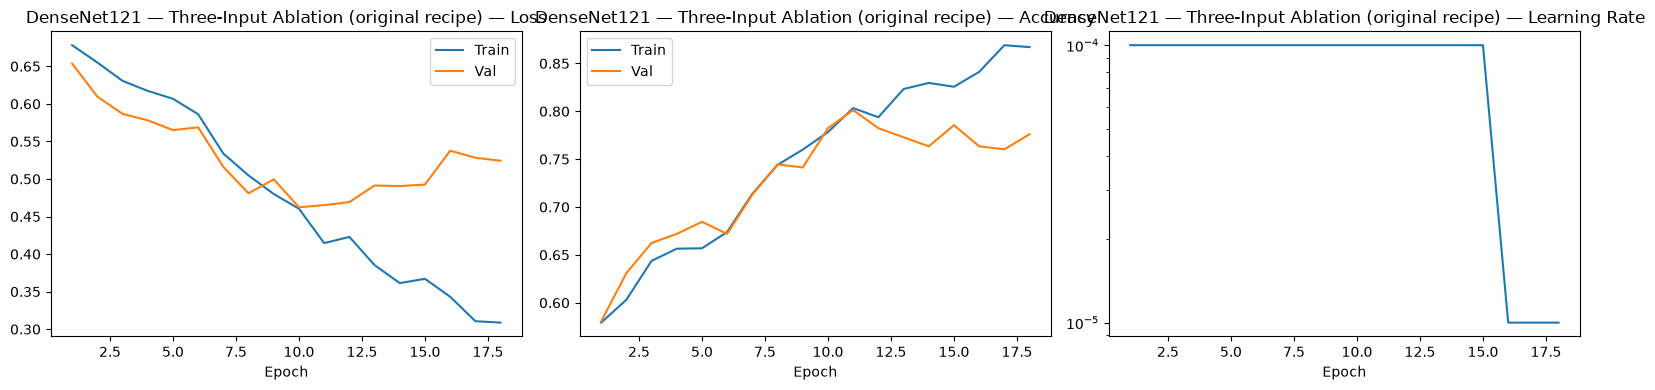

eval densenet121-test:   0%|          | 0/20 [00:00<?, ?it/s]

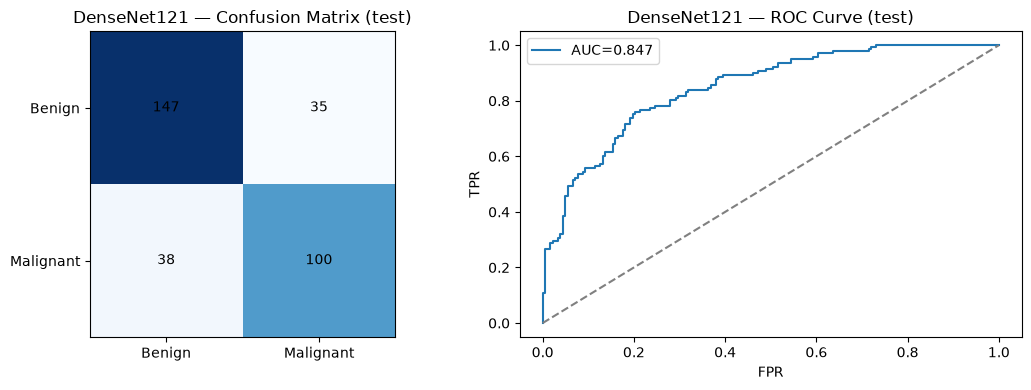

              precision    recall  f1-score   support

      Benign       0.79      0.81      0.80       182
   Malignant       0.74      0.72      0.73       138

    accuracy                           0.77       320
   macro avg       0.77      0.77      0.77       320
weighted avg       0.77      0.77      0.77       320


Experiment: stage0_three_input_ablation_resnet50  (arch=resnet50)
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau | full unfreeze, no label smoothing


stage0_three_input_ablation_resnet50 e1 [warmup-train]:   0%|          | 0/157 [00:00<?, ?it/s]

stage0_three_input_ablation_resnet50 e1 [warmup-val]:   0%|          | 0/20 [00:00<?, ?it/s]

  [warmup] epoch  1 | train_loss 0.6757 acc 0.5792 | val_loss 0.6557 acc 0.6688


stage0_three_input_ablation_resnet50 e2 [warmup-train]:   0%|          | 0/157 [00:00<?, ?it/s]

...

stage0_three_input_ablation_resnet50 e16 [val]:   0%|          | 0/20 [00:00<?, ?it/s]

  epoch 16 | train_loss 0.3660 acc 0.8284 | val_loss 0.5383 acc 0.7855 | lr(head) 1.00e-05


stage0_three_input_ablation_resnet50 e17 [train]:   0%|          | 0/157 [00:00<?, ?it/s]

stage0_three_input_ablation_resnet50 e17 [val]:   0%|          | 0/20 [00:00<?, ?it/s]

  epoch 17 | train_loss 0.3632 acc 0.8272 | val_loss 0.5347 acc 0.7886 | lr(head) 1.00e-05
  Early stopping at epoch 17.


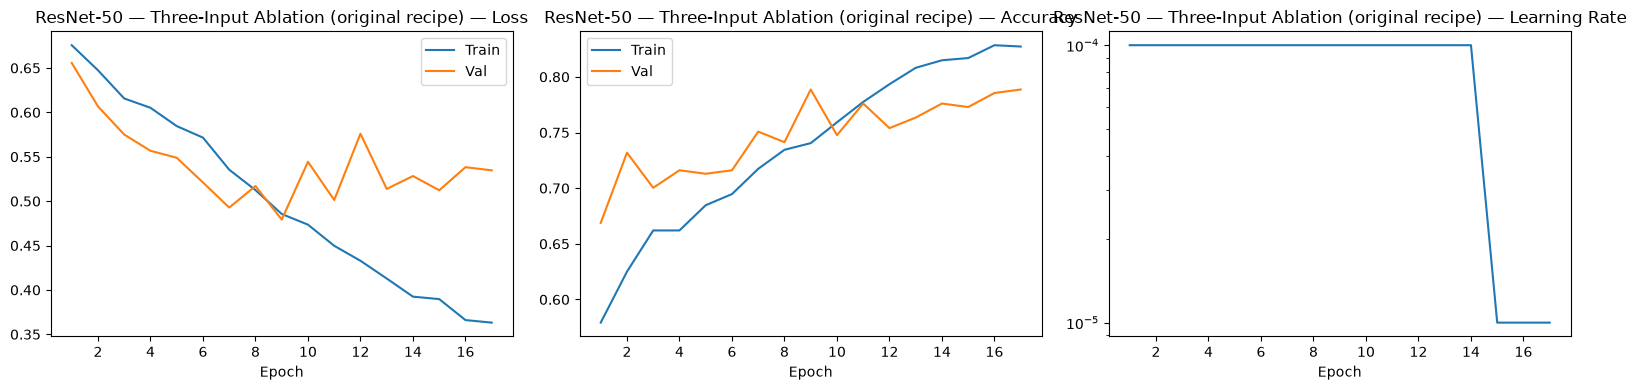

eval resnet50-test:   0%|          | 0/20 [00:00<?, ?it/s]

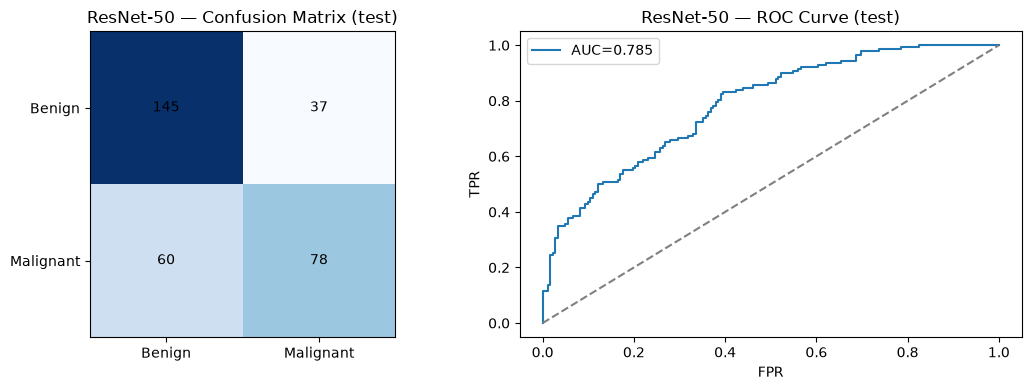

              precision    recall  f1-score   support

      Benign       0.71      0.80      0.75       182
   Malignant       0.68      0.57      0.62       138

    accuracy                           0.70       320
   macro avg       0.69      0.68      0.68       320
weighted avg       0.69      0.70      0.69       320


Experiment: stage0_three_input_ablation_efficientnet_b2  (arch=efficientnet_b2)
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau | full unfreeze, no label smoothing


stage0_three_input_ablation_efficientnet_b2 e1 [warmup-train]:   0%|          | 0/157 [00:00<?, ?it/s]

stage0_three_input_ablation_efficientnet_b2 e1 [warmup-val]:   0%|          | 0/20 [00:00<?, ?it/s]

  [warmup] epoch  1 | train_loss 0.6523 acc 0.6091 | val_loss 0.6188 acc 0.6877


stage0_three_input_ablation_efficientnet_b2 e2 [warmup-train]:   0%|          | 0/157 [00:00<?, ?it/s]

...

stage0_three_input_ablation_efficientnet_b2 e21 [val]:   0%|          | 0/20 [00:00<?, ?it/s]

  epoch 21 | train_loss 0.3425 acc 0.8436 | val_loss 0.5818 acc 0.7697 | lr(head) 1.00e-05


stage0_three_input_ablation_efficientnet_b2 e22 [train]:   0%|          | 0/157 [00:00<?, ?it/s]

stage0_three_input_ablation_efficientnet_b2 e22 [val]:   0%|          | 0/20 [00:00<?, ?it/s]

  epoch 22 | train_loss 0.3441 acc 0.8443 | val_loss 0.5778 acc 0.7603 | lr(head) 1.00e-05
  Early stopping at epoch 22.


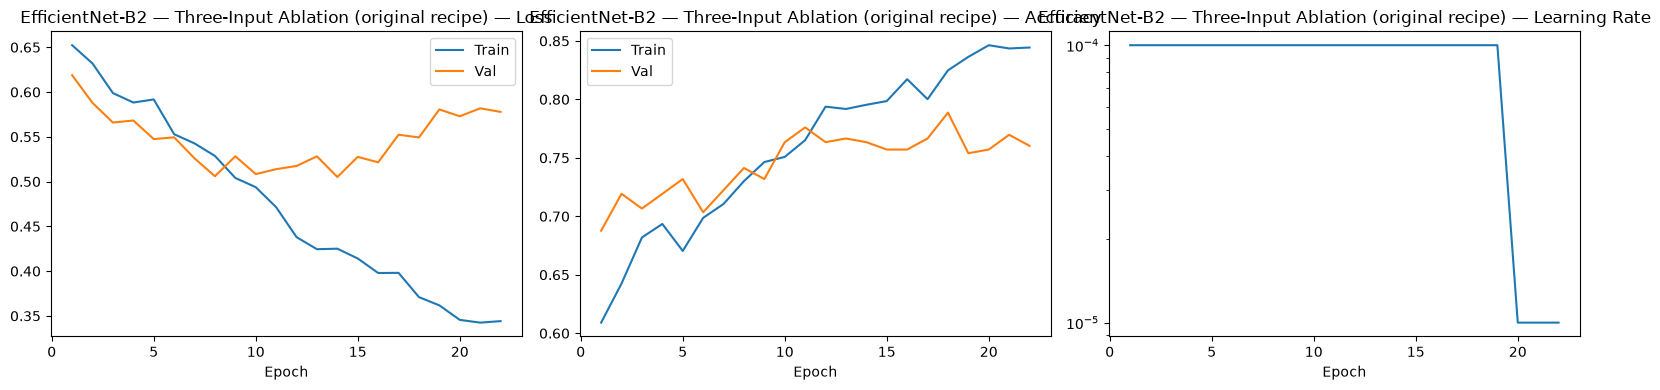

eval efficientnet_b2-test:   0%|          | 0/20 [00:00<?, ?it/s]

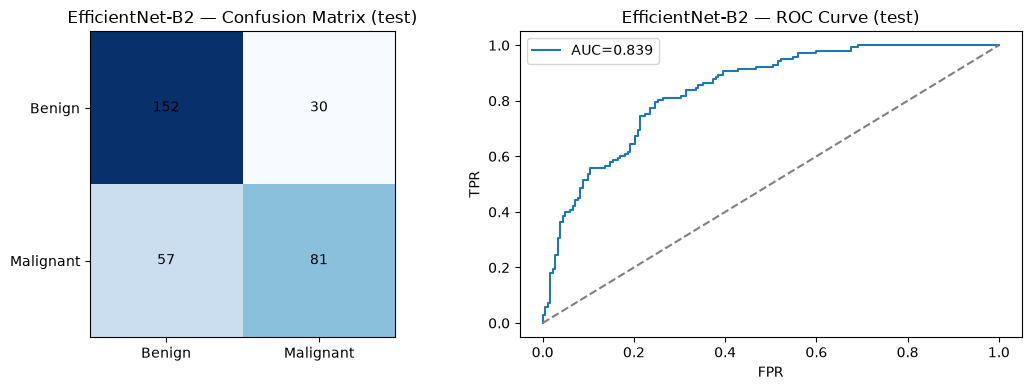

              precision    recall  f1-score   support

      Benign       0.73      0.84      0.78       182
   Malignant       0.73      0.59      0.65       138

    accuracy                           0.73       320
   macro avg       0.73      0.71      0.71       320
weighted avg       0.73      0.73      0.72       320


Experiment: stage0_three_input_ablation_vgg16  (arch=vgg16)
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau | full unfreeze, no label smoothing


stage0_three_input_ablation_vgg16 e1 [warmup-train]:   0%|          | 0/157 [00:00<?, ?it/s]

stage0_three_input_ablation_vgg16 e1 [warmup-val]:   0%|          | 0/20 [00:00<?, ?it/s]

  [warmup] epoch  1 | train_loss 0.6677 acc 0.5991 | val_loss 0.6344 acc 0.5962


stage0_three_input_ablation_vgg16 e2 [warmup-train]:   0%|          | 0/157 [00:00<?, ?it/s]

...

stage0_three_input_ablation_vgg16 e14 [val]:   0%|          | 0/20 [00:00<?, ?it/s]

  epoch 14 | train_loss 0.2813 acc 0.8754 | val_loss 0.6176 acc 0.7634 | lr(head) 1.00e-05


stage0_three_input_ablation_vgg16 e15 [train]:   0%|          | 0/157 [00:00<?, ?it/s]

stage0_three_input_ablation_vgg16 e15 [val]:   0%|          | 0/20 [00:00<?, ?it/s]

  epoch 15 | train_loss 0.2577 acc 0.8881 | val_loss 0.6574 acc 0.7539 | lr(head) 1.00e-05
  Early stopping at epoch 15.


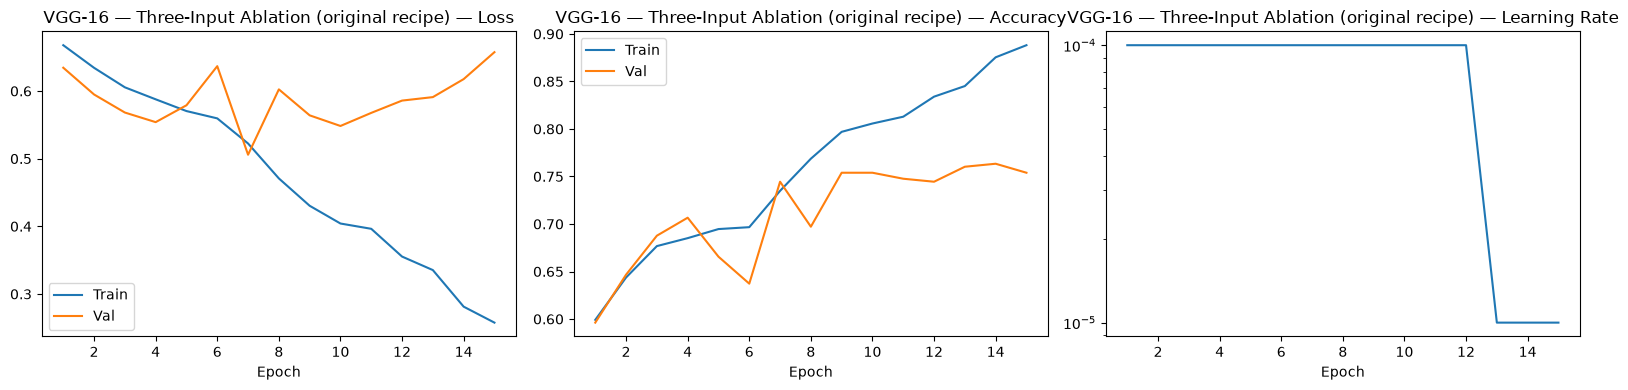

eval vgg16-test:   0%|          | 0/20 [00:00<?, ?it/s]

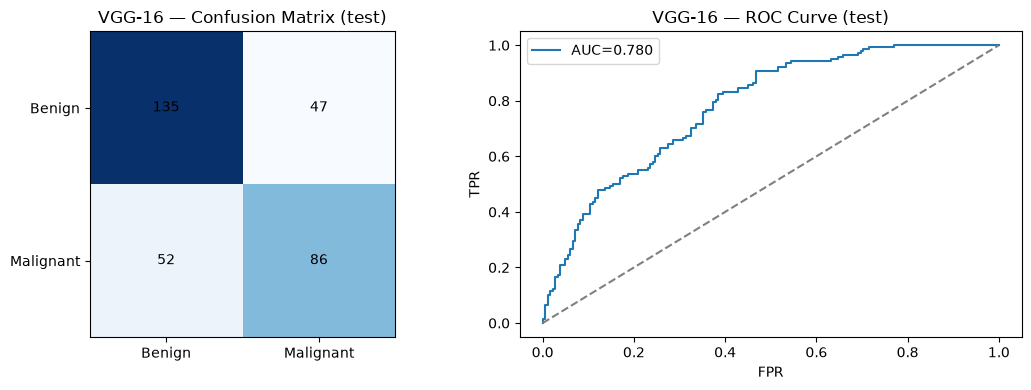

              precision    recall  f1-score   support

      Benign       0.72      0.74      0.73       182
   Malignant       0.65      0.62      0.63       138

    accuracy                           0.69       320
   macro avg       0.68      0.68      0.68       320
weighted avg       0.69      0.69      0.69       320

Saved test-set comparison metrics to results\three_input_ablation_test_metrics.csv


,model,architecture,accuracy,sensitivity,specificity,f1,roc_auc,best_val_accuracy,best_epoch,epochs_run,training_time_sec,checkpoint_path
0,DenseNet121,densenet121,0.771875,0.724638,0.807692,0.732601,0.847189,0.782334,10,18,1246.1,checkpoints\stage0_three_input_ablation_densen...
1,ResNet-50,resnet50,0.696875,0.565217,0.796703,0.616601,0.784759,0.788644,9,17,903.3,checkpoints\stage0_three_input_ablation_resnet...
2,EfficientNet-B2,efficientnet_b2,0.728125,0.586957,0.835165,0.650602,0.838987,0.763407,14,22,1208.5,checkpoints\stage0_three_input_ablation_effici...
3,VGG-16,vgg16,0.690625,0.623188,0.741758,0.634686,0.779861,0.744479,7,15,1166.3,checkpoints\stage0_three_input_ablation_vgg16.pth


In [8]:
train_loader, val_loader, test_loader = make_loaders()

ablation_results = []
ablation_histories = {}
ablation_test_evals = {}

for arch in ARCHITECTURES:
    display_name = ARCH_DISPLAY_NAMES[arch]
    exp_name = f"stage0_three_input_ablation_{arch}"

    hist, ckpt, row = train_experiment(
        exp_name=exp_name, arch=arch,
        head_lr=BASELINE["head_lr"], backbone_lr=BASELINE["backbone_lr"],
        weight_decay=BASELINE["weight_decay"], scheduler_name=BASELINE["scheduler"],
        train_loader=train_loader, val_loader=val_loader,
    )
    ablation_histories[arch] = hist
    plot_curves(hist, f"{display_name} — Three-Input Ablation (original recipe)")

    test_eval = evaluate_checkpoint(row["checkpoint_path"], arch, test_loader, tag=f"{arch}-test")
    ablation_test_evals[arch] = test_eval
    plot_confusion_and_roc(test_eval, display_name)

    result_row = {
        "model": display_name,
        "architecture": arch,
        **test_eval["metrics"],
        "best_val_accuracy": row["best_val_accuracy"],
        "best_epoch": row["best_epoch"],
        "epochs_run": row["epochs_run"],
        "training_time_sec": row["training_time_sec"],
        "checkpoint_path": row["checkpoint_path"],
    }
    ablation_results.append(result_row)

ablation_df = pd.DataFrame(ablation_results)
ablation_csv_path = os.path.join(RESULTS_DIR, "three_input_ablation_test_metrics.csv")
ablation_df.to_csv(ablation_csv_path, index=False)
print(f"Saved test-set comparison metrics to {ablation_csv_path}")
ablation_df


## Three-way comparison: two-input baseline vs. three-input+fixes (regressed) vs. this ablation (ROI only, original recipe)

This is the number that actually answers "does ROI help": compare `ablation_accuracy` to
`two_input_baseline_accuracy`. If ablation >= baseline, the ROI mask has real value and the
overfitting-fix bundle from `three_input_coach_comparison.ipynb` needs separate, more careful
tuning (rather than the current all-at-once combination). If ablation is still below baseline,
the ROI mask itself isn't adding useful signal on top of the crop for this task/architecture set,
and the earlier hypothesis -- that crop already captures most of the localization benefit, and the
mask mostly adds a hard-to-use modality on top -- is the more likely explanation.

In [9]:
dual_input_df = pd.read_csv(os.path.join(RESULTS_DIR, "architecture_comparison_test_metrics.csv"))
three_input_fixes_df = pd.read_csv(os.path.join(RESULTS_DIR, "three_input_coach_comparison_test_metrics.csv")) \
    if os.path.exists(os.path.join(RESULTS_DIR, "three_input_coach_comparison_test_metrics.csv")) else None

comparison = ablation_df[["architecture", "model", "accuracy", "roc_auc"]].rename(
    columns={"accuracy": "ablation_accuracy", "roc_auc": "ablation_roc_auc"}
).merge(
    dual_input_df[["architecture", "accuracy", "roc_auc"]].rename(
        columns={"accuracy": "two_input_baseline_accuracy", "roc_auc": "two_input_baseline_roc_auc"}
    ),
    on="architecture",
)
comparison["accuracy_gain_vs_two_input"] = (
    comparison["ablation_accuracy"] - comparison["two_input_baseline_accuracy"]
)

if three_input_fixes_df is not None:
    comparison = comparison.merge(
        three_input_fixes_df[["architecture", "accuracy"]].rename(columns={"accuracy": "three_input_with_fixes_accuracy"}),
        on="architecture", how="left",
    )

comparison


,architecture,model,ablation_accuracy,ablation_roc_auc,two_input_baseline_accuracy,two_input_baseline_roc_auc,accuracy_gain_vs_two_input
0,densenet121,DenseNet121,0.771875,0.847189,0.779141,0.861702,-0.007266
1,resnet50,ResNet-50,0.696875,0.784759,0.717791,0.796755,-0.020916
2,efficientnet_b2,EfficientNet-B2,0.728125,0.838987,0.769939,0.844743,-0.041814
3,vgg16,VGG-16,0.690625,0.779861,0.745399,0.834258,-0.054774
